# Plot of comparing the performances when distinguishing multiple LLM from one another

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
from matplotlib.patches import FancyBboxPatch


sys.path.append("../src")
import utils

In [2]:
# -------------------------
# Style (ICML-friendly)
# -------------------------
# plt.rcParams.update({
#     "font.size": 11,
#     "axes.labelsize": 12,
#     "axes.titlesize": 12,
#     "legend.fontsize": 10,
#     "lines.linewidth": 2.0,
#     "lines.markersize": 6,
#     "pdf.fonttype": 42,   # editable text in PDF
#     "ps.fonttype": 42,
# })

plt.rcParams.update({
    # Figure size - ICML typically uses two-column format
    'figure.figsize': (3.25, 2.5),  # Single column width
    # 'figure.figsize': (6.75, 2.5),  # Double column width
    
    # Font sizes
    'font.size': 10,           # Base font size
    'axes.labelsize': 11,      # X and Y labels
    'axes.titlesize': 11,      # Title
    'xtick.labelsize': 9,      # X tick labels
    'ytick.labelsize': 9,      # Y tick labels
    'legend.fontsize': 8,      # Legend
    
    # Font family
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Use LaTeX for text rendering (optional but recommended)
    'text.usetex': False,  # Set to True if you have LaTeX installed
    
    # Line widths
    'axes.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    
    # Grid
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
    
    # Ticks
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    
    # Legend
    'legend.frameon': True,
    'legend.framealpha': 0.8,
    'legend.fancybox': False,
    'legend.edgecolor': 'black',
    
    # Save settings
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'savefig.format': 'pdf',  # PDF is preferred for publications
})



In [3]:
data = [
    # Total 4k sentences
    ["Llama3.1-8B", "Fresh news", 20, 150, 0.41052, 0.6025],
    ["Llama3.1-8B", "Fresh news", 15, 266, 0.4636, 0.6793],
    ["Llama3.1-8B", "Fresh news", 10, 400, 0.5591, 0.7913],
    ["Llama3.1-8B", "Fresh news", 7, 570, 0.6720, 0.8897],
    ["Llama3.1-8B", "Fresh news", 5, 800, 0.6694, 0.885],
    ["Llama3.1-8B", "Fresh news", 3, 1300, 0.8111, 0.9423],
    ["Llama3.1-8B", "Fresh news", 2, 1900, 0.8924, 0.9868],

    # With an other offset

    # NEED RERUN FOR CLASSIFICATION
    ["Llama3.1-8B", "Fresh news", 20, 150, 0.4258, 0.6625],
    ["Llama3.1-8B", "Fresh news", 15, 266, 0.4666, 0.6491],
    ["Llama3.1-8B", "Fresh news", 10, 400, 0.5845, 0.815],
    ["Llama3.1-8B", "Fresh news", 7, 570, 0.7003, 0.8835],
    ["Llama3.1-8B", "Fresh news", 5, 800, 0.7641, 0.94],
    ["Llama3.1-8B", "Fresh news", 3, 1300, 0.8462, 0.9410],
    ["Llama3.1-8B", "Fresh news", 2, 1900, 0.902, 0.9671],

]

In [4]:
df = pd.DataFrame(
    data,
    columns=[
        "Model name",
        "Dataset name",

        "num classes",

        "total prompts",

        "Token-wise F1-score",
        "Text-wise F1-score",

    ],
)

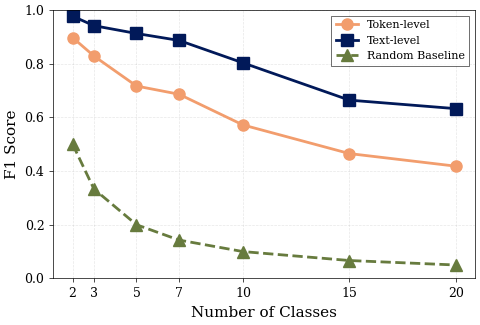


Both bar and line plots have been generated!


In [6]:
# Group by number of classes and calculate means
grouped = df.groupby('num classes').agg({
    'Token-wise F1-score': 'mean',
    'Text-wise F1-score': 'mean'
}).reset_index()

# Calculate random baseline (1/num_classes)
grouped['Random Baseline'] = 1 / grouped['num classes']

colors_palette = [utils.batlow_categorical_colors[i] for i in [4, 0, 13]]#[0 , 1, 5,  4, 6]]

# Alternative: Line plot version (more suitable if you have many class values)
fig2, ax2 = plt.subplots(figsize=(5.0, 3.45))

ax2.plot(grouped['num classes'], grouped['Token-wise F1-score'], 
         marker='o', linewidth=2, markersize=8, label='Token-level', color=colors_palette[0])
ax2.plot(grouped['num classes'], grouped['Text-wise F1-score'], 
         marker='s', linewidth=2, markersize=8, label='Text-level', color=colors_palette[1])
ax2.plot(grouped['num classes'], grouped['Random Baseline'], 
         marker='^', linewidth=2, markersize=8, label='Random Baseline', 
         color=colors_palette[2], linestyle='--')

ax2.set_xlabel('Number of Classes')
ax2.set_ylabel('F1 Score')
# ax2.set_title('Performance Comparison Across Different Number of Classes', fontweight='bold', pad=15)
ax2.legend(frameon=True, fancybox=False, shadow=False)
ax2.grid(alpha=0.3, linestyle='--', linewidth=0.5)
ax2.set_ylim(0, 1.0)

ax2.set_xticks(grouped['num classes'])



plt.tight_layout()
plt.savefig('multi-llm-attribution.pdf') #, bbox_inches='tight', dpi=300)
# plt.savefig('metrics_comparison_line.png', bbox_inches='tight', dpi=300)

plt.show()

print("\nBoth bar and line plots have been generated!")